:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`plot_03_population_glm.ipynb`**!

:::

In [1]:
%matplotlib inline
import warnings

# Ignore the first specific warning
warnings.filterwarnings(
    "ignore",
    message="plotting functions contained within `_documentation_utils` are intended for nemos's documentation.",
    category=UserWarning,
)

# Ignore the second specific warning
warnings.filterwarnings(
    "ignore",
    message="Ignoring cached namespace 'core'",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message=(
        "invalid value encountered in div "
    ),
    category=RuntimeWarning,
)

# Population GLM

Fitting the activity of a neural population with NeMoS can be much more efficient than fitting each individual
neuron in a loop. The reason for this is that NeMoS leverages the powerful GPU-vectorization implemented by `JAX`.


:::{note}
For an unregularized, Lasso, Ridge, or group-Lasso GLM, fitting a GLM one neuron at the time, or fitting jointly
the neural population is equivalent. The main difference between the approaches is that the former is more
memory efficient, the latter is computationally more efficient (it takes less time to fit).
:::

## Fitting a Population GLM

NeMoS has a dedicated [`nemos.GLM.PopulationGLM`](nemos.glm.PopulationGLM) class for fitting jointly a neural population. The API
 is very similar to that the regular [`GLM`](nemos.glm.GLM), but with a few differences:

 1. The `y` input to the methods [`fit`](nemos.glm.PopulationGLM.fit) and [`score`](nemos.glm.PopulationGLM.score) must be a two-dimensional array of shape `(n_samples, n_neurons)`.
 2. You can optionally pass a `feature_mask` in the form of an array of 0s and 1s with shape `(n_features, n_neurons)`
 that specifies which features are used as predictors for each neuron. More on this [later](#neuron-specific-features).

Let's generate some synthetic data and fit a population model.

In [2]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

import numpy as np

import nemos as nmo

np.random.seed(123)

n_features = 5
n_neurons = 2
n_samples = 500

# random design array. Shape (n_time_points, n_features).
X = 0.5*np.random.normal(size=(n_samples, n_features))

# log-rates & weights
b_true = np.zeros((n_neurons, ))
w_true = np.random.uniform(size=(n_features, n_neurons))


# generate counts (spikes will be (n_samples, n_features)
rate = jnp.exp(jnp.dot(X, w_true) + b_true)
spikes = np.random.poisson(rate)

print(spikes.shape)

(500, 2)


We can now instantiate the [`PopulationGLM`](nemos.glm.PopulationGLM) model and  fit.

In [3]:
model = nmo.glm.PopulationGLM()
model.fit(X, spikes)

print(f"population GLM log-likelihood: {model.score(X, spikes)}")

population GLM log-likelihood: -1.3108174800872803


(neuron-specific-features)=
## Neuron-specific features
If you want to model neurons with different input features, the way to do so is to specify a `feature_mask`.
Let's assume that we have two neurons, share one shared input, and have an extra private one, for a total of
3 inputs.

In [4]:
# let's take the first three input
n_features = 3
input_features = X[:, :3]

Let's assume that:

  - `input_features[:, 0]` is shared.
  - `input_features[:, 1]` is an input only for the first neuron.
  - `input_features[:, 2]` is an input only for the second neuron.

We can simulate this scenario,

In [5]:
# model the rate of the first neuron using only the first two features and weights.
rate_neuron_1 = jnp.exp(np.dot(input_features[:, [0, 1]], w_true[: 2, 0]))

# model the rate of the second neuron using only the first and last feature and weights.
rate_neuron_2 = jnp.exp(np.dot(input_features[:, [0, 2]], w_true[[0, 2], 1]))

# stack the rates in a (n_samples, n_neurons) array and generate spikes
rate = np.hstack((rate_neuron_1[:, np.newaxis], rate_neuron_2[:, np.newaxis]))
spikes = np.random.poisson(rate)

We can impose the same constraint to the [`PopulationGLM`](nemos.glm.PopulationGLM) by masking the weights.

In [6]:
# initialize the mask to a matrix of 1s.
feature_mask = np.ones((n_features, n_neurons))

# remove the 3rd feature from the predictors of the first neuron
feature_mask[2, 0] = 0

# remove the 2nd feature from the predictors of the second neuron
feature_mask[1, 1] = 0

# visualize the mask
print(feature_mask)

[[1. 1.]
 [1. 0.]
 [0. 1.]]


The mask can be passed at initialization or set after the model is initialized, but cannot be changed
after the model is fit.

In [7]:
# set a quasi-newton solver and low tolerance for better numerical precision
model = nmo.glm.PopulationGLM(solver_name="LBFGS", solver_kwargs={"tol": 10**-12})

# set the mask
model.feature_mask = feature_mask

# fit the model
model.fit(input_features, spikes)

,observation_model,PoissonObservations()
,inverse_link_function,<function exp...x7f9eadf1a700>
,regularizer,UnRegularized()
,solver_name,'LBFGS'
,solver_kwargs,{'tol': 1e-12}
,feature_mask,"Array([[1., 1...dtype=float32)"
,regularizer_strength,None
,fit_intercept,True
Name,Type,Value
aux_,NoneType,None
coef_,"ArrayImpl[float32](3, 2)",Array([[0.562...dtype=float32)


If we print the model coefficients, we can see the effect of the mask.

In [8]:
print(model.coef_)

[[0.56283075 0.2565422 ]
 [0.02549857 0.        ]
 [0.         0.16695638]]


The coefficient for the first neuron corresponding to the last feature is zero, as well as
the coefficient of the second neuron corresponding to the second feature.

To convince ourselves that this is equivalent to fit each neuron individually with the correct features,
let's go ahead and try.

/home/jenkins/agent/workspace/CCN_nemos_PR-616/venv/lib/python3.12/site-packages/nemos/glm/glm.py:1045: RuntimeWarning: The fit did not converge. Consider the following:
1) Enable float64 with ``jax.config.update('jax_enable_x64', True)`` 
2) Increase the max number of iterations or increase tolerance (if reasonable). These parameters can be specified by providing a ``solver_kwargs`` dictionary. For the available options see the ``self.solver.__init__`` docstrings.
  warnings.warn(


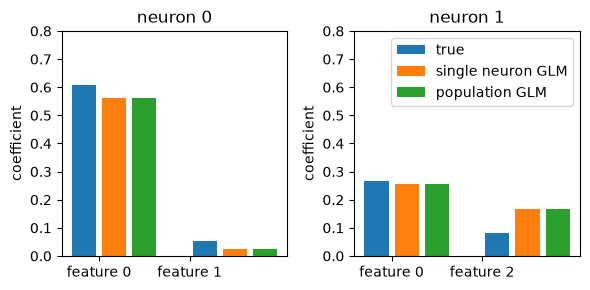

In [9]:
# features for each neuron
features_by_neuron = {
    0: [0, 1],
    1: [0, 2]
}
# initialize the coefficients
coeff = np.zeros((2, 2))

# loop over the neurons and fit a GLM
for neuron in range(2):
    model_neu = nmo.glm.GLM(
        solver_name="LBFGS", solver_kwargs={"tol":10**-12}
    )
    model_neu.fit(input_features[:, features_by_neuron[neuron]], spikes[:, neuron])
    coeff[:, neuron] = model_neu.coef_

# visually compare the estimated coeffeicients
fig, axs = plt.subplots(1, 2, figsize=(6, 3))
for neuron in range(2):
    axs[neuron].set_title(f"neuron {neuron}")
    axs[neuron].bar([0, 4], w_true[features_by_neuron[neuron], neuron], width=0.8, label="true")
    axs[neuron].bar([1, 5], coeff[:, neuron], width=0.8, label="single neuron GLM")
    axs[neuron].bar([2, 6], model.coef_[features_by_neuron[neuron], neuron], width=0.8, label="population GLM")
    axs[neuron].set_ylabel("coefficient")
    axs[neuron].set_ylim(0, 0.8)
    axs[neuron].set_xticks([0.5, 3.5])
    axs[neuron].set_xticklabels(["feature 0", f"feature {neuron + 1}"])
    if neuron == 1:
        plt.legend()
plt.tight_layout()

In [10]:
# save image for thumbnail
from pathlib import Path
import os

root = os.environ.get("READTHEDOCS_OUTPUT")
if root:
   path = Path(root) / "html/_static/thumbnails/how_to_guide"
# if local store in ../_build/html/...
else:
   path = Path("../_build/html/_static/thumbnails/how_to_guide")

# make sure the folder exists if run from build
if root or Path("../assets/stylesheets").exists():
   path.mkdir(parents=True, exist_ok=True)

if path.exists():
  fig.savefig(path / "plot_03_population_glm.svg")

## Pytrees
[`PopulationGLM`](nemos.glm.PopulationGLM) is compatible with JAX [`pytrees`](https://docs.jax.dev/en/latest/pytrees.html), which are general, potentially nested, container-like structures. Pytrees include lists, dictionaries, tuples or any combination thereof. If you structure your predictors
in a pytree, the `feature_mask` must be a pytree of the same structure, each leaf shaped like
the coefficients it masks, `(n_features_in_leaf, n_neurons)`.
For example, if we use a Python `dict`, the example above can be reformulated as follows,

In [11]:
# restructure the input as dict (a type of pytree)
pytree_features = dict(
    shared=input_features[:, :1],
    neu_0=input_features[:, 1:2],
    neu_1=input_features[:, 2:]
)

# Define a mask as a dictionary. Each group holds a single feature here, so each leaf has
# shape (1, n_neurons).
pytree_mask = dict(
    shared=np.array([[1, 1]]),
    neu_0=np.array([[1, 0]]),
    neu_1=np.array([[0, 1]])
)

# fit a model
model_tree = nmo.glm.PopulationGLM(solver_name="LBFGS", feature_mask=pytree_mask)
model_tree.fit(pytree_features, spikes)

# print the coefficients
print(model_tree.coef_)

{'neu_0': Array([[0.02549865, 0.        ]], dtype=float32), 'neu_1': Array([[0.        , 0.16696058]], dtype=float32), 'shared': Array([[0.5628304 , 0.25654164]], dtype=float32)}


:::{note} Migrating a pytree `feature_mask` from nemos 0.2.9 or earlier

In nemos 0.2.9 and earlier, a pytree `feature_mask` held one entry per neuron in each leaf, shape `(n_neurons,)`, so a single entry included or excluded an entire input group for that neuron. Leaves now match the coefficients they mask, shape `(n_features_in_leaf, n_neurons)`, which also lets you mask individual features inside a group. A mask in the old form is rejected with a shape error.

Expanding each leaf along the feature axis reproduces the old masking exactly. For the mask above, whose groups happen to hold one feature each:

```python
# nemos <= 0.2.9: one entry per neuron
pytree_mask = dict(
    shared=np.array([1, 1]),
    neu_0=np.array([1, 0]),
    neu_1=np.array([0, 1]),
)

# equivalent today: one entry per coefficient
pytree_mask = dict(
    shared=np.array([[1, 1]]),
    neu_0=np.array([[1, 0]]),
    neu_1=np.array([[0, 1]]),
)
```

With more than one feature per group, every feature of a group shared its neuron's flag, so broadcasting against the predictors gives the same model:

```python
pytree_mask = {
    key: np.broadcast_to(mask, (pytree_features[key].shape[1], *mask.shape))
    for key, mask in old_pytree_mask.items()
}
```
:::